# Assignment 04

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

## 1. Global Earthquakes

In this problem set, we will use [this file](https://zhu-group.github.io/ese5023/download/usgs_earthquakes.csv) from the USGS Earthquakes Database. The dataset is similar to the one you use in [Assignment 02](https://zhu-group.github.io/ese5023/Assignment_02.html#1_Significant_earthquakes_since_2150_BC). Use the file provided (usgs_earthquakes.csv) to recreate the following map. Use the mag column for magnitude. [10 points]

![](https://zhu-group.github.io/ese5023/figs/earthquakes.png)

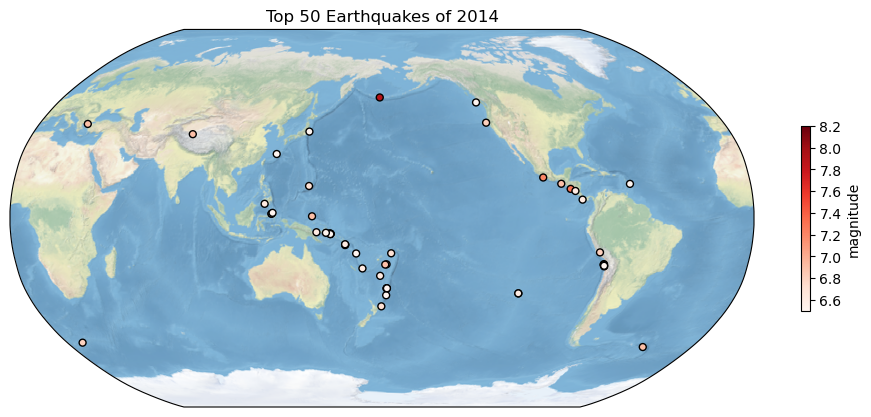

In [99]:
df = pd.read_csv("./data/usgs_earthquakes.csv", parse_dates=["time"])
df = df.loc[pd.DatetimeIndex(df["time"]).year==2014]
df = df.sort_values(by="mag", ascending=False).iloc[0:50]

fig = plt.figure(figsize=np.array([8, 4])*1.5, dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0], projection=ccrs.Robinson(central_longitude=-180))
ax.set_extent([0.1, 359.9, -90, 90])
ar = ax.scatter(df["longitude"], df["latitude"], s=25, c=df["mag"], cmap="Reds", ec="k", transform=ccrs.PlateCarree())
ax.stock_img()
ax.set_title("Top 50 Earthquakes of 2014")
fig.colorbar(ar, ax=ax, label="magnitude", ticks=np.arange(6.6, 8.3, 0.2), shrink=0.4)

## 2. Explore a netCDF dataset

Browse the NASA’s Goddard Earth Sciences Data and Information Services Center (GES DISC) [website](https://disc.gsfc.nasa.gov/). Search and download a dataset you are interested in. You are also welcome to use data from your group in this problem set. But the dataset should be in netCDF format. For this problem set, you are welcome to use the same dataset you used in [Assignment 03](https://zhu-group.github.io/ese5023/Assignment_03.html#3_Explore_a_netCDF_dataset).

### 2.1 [10 points]

Make a global map of a certain variable. Your figure should contain: a project, x label and ticks, y label and ticks, title, gridlines, legend, colorbar, masks or features, annotations, and text box (1 point each).

In [53]:
# data for Figure (a, b, d, e)
ds = xr.open_dataset("./data/HAQ_TROPOMI_NO2_GLOBAL_QA75_L3_Monthly_Mean_V2.4_201901_to_202508.nc")
ds_select_china = ds.sel(lon=slice(65, 140), lat=slice(10, 60))
mask_world_land = xr.open_dataset("./data/mask_world_country.nc")["mask"].values
ds_land = ds.copy()
mask_world_land[mask_world_land>=0] = 1
ds_land["Tropospheric_NO2"] *= mask_world_land
no2_lat = ds_land["Tropospheric_NO2"].groupby(ds_land.lat).mean(dim=["lon", "lat"])
no2 = ds["Tropospheric_NO2"].values

# cartopy feature
gdf_world = gpd.read_file("./data/world.zh.json")
gdf_china = gpd.read_file("./data/china_province.geojson").sort_values(by="gb")
geojson_world = gdf_world["geometry"]
geojson_china = gdf_china["geometry"]
gdf_china = gdf_china.loc[gdf_china["name"]!="境界线"]
gdf_china.reset_index(inplace=True)
shp_world = cfeature.ShapelyFeature(geojson_world, ccrs.PlateCarree(), fc="none", ec="k", lw=0.5)
shp_china = cfeature.ShapelyFeature(geojson_china, ccrs.PlateCarree(), fc="none", ec="k", lw=0.5)

Text(0.98, 0.03, 'Created: 2025-11-26 21:34:53')

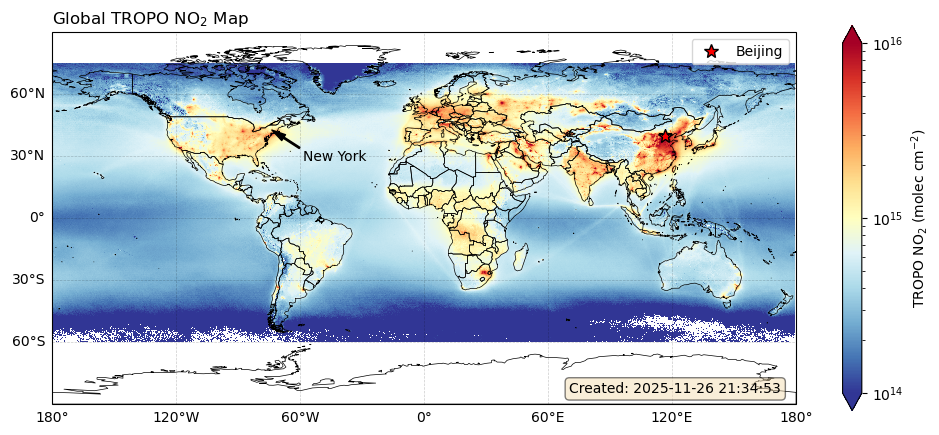

In [100]:
import matplotlib.lines as mlines
blue_line = mlines.Line2D([], [], color='blue', marker='*',
                          markersize=15, label='Blue stars')

fig = plt.figure(figsize=[12, 5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)

# Project
ax = fig.add_subplot(spec[0], projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90])
# Map
ar = ax.pcolormesh(ds["lon"], ds["lat"], ds["Tropospheric_NO2"], norm=mpl.colors.LogNorm(vmin=1e14, vmax=1e16), cmap="RdYlBu_r", transform=ccrs.PlateCarree())
# Features
ax.add_feature(shp_world)
# Gridlines, X-ticks, Y-ticks
gl = ax.gridlines(color="k", linestyle="--", lw=0.5, draw_labels=True, x_inline=False, y_inline=False, dms=True, alpha=0.2)
gl.top_labels, gl.right_labels, gl.rotate_labels = False, False, False
# Title
ax.set_title(r"Global TROPO NO$_2$ Map", loc="left")
# X-label, Y-label
# ax.set(xlabel="Longitude", ylabel="Latitude")
# Legend
ax.plot([116.40753], [39.90403], "r*", mec="k", ms=10, label="Beijing", transform=ccrs.PlateCarree())
ax.legend(loc='upper right', bbox_to_anchor=(1, 1))
# Colorbar
fig.colorbar(ar, ax=ax, extend="both", label=r"TROPO NO$_2$ (molec cm$^{-2}$)")
# Annotate
ax.annotate("New York", xy=(-73.754968, 42.6511674), xytext=(-73.754968+15, 42.6511674-15), arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=5, headlength=10), transform=ccrs.PlateCarree())
# Text box
ax.text(0.98, 0.03, "Created: 2025-11-26 21:34:53", transform=ax.transAxes, horizontalalignment="right", bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

### 2.2 [10 points]

Make a regional map of the same variable. Your figure should contain: a different project, x label and ticks, y label and ticks, title, gridlines, legend, colorbar, masks or features, annotations, and text box (1 point each).

[Text(0.5, 0, 'Longitude'), Text(0, 0.5, 'Latitude')]

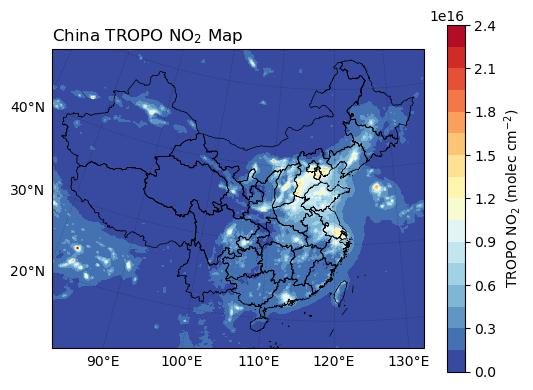

In [101]:
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
# Projection
ax = fig.add_subplot(spec[0], projection=ccrs.LambertConformal(central_longitude=120, central_latitude=34, standard_parallels=[20, 40]))
ax.set_extent([82, 132, 16, 51])
ar = ax.contourf(ds_select_china["lon"], ds_select_china["lat"], ds_select_china["Tropospheric_NO2"], levels=20, cmap="RdYlBu_r", transform=ccrs.PlateCarree())
fig.colorbar(ar, ax=ax, extend="both", label=r"TROPO NO$_2$ (molec cm$^{-2}$)")
# gdf_china.plot(ax=ax, column="no2", cmap="RdYlBu_r", norm=mpl.colors.LogNorm(vmin=1e14, vmax=1e16), legend=True)
ax.add_feature(shp_china)
gl = ax.gridlines(color="k", linestyle="--", lw=0.5, draw_labels=["bottom", "left"], x_inline=False, y_inline=False, dms=True, alpha=0.2, rotate_labels=False)
ax.set_title(r"China TROPO NO$_2$ Map", loc="left")
ax.set(xlabel="Longitude", ylabel="Latitude")